In [ ]:
import pandas as pd
df = pd.read_csv('/media/zihengc/T7/mpra3_lib_analysis/indexing/MPRA3_Contributor_20231108_unique_GeneName_BarcodeEnhancerPair.csv',index_col=0 )
df = df.drop_duplicates('enhancer_id').set_index('enhancer_id')
df = df[['enhancer_seq']]
df['index'] = range(1, len(df) + 1)

output_filename = "/media/zihengc/T7/mpra3_lib_analysis/indexing/enhancer_sequences.fasta"

# Write out the DataFrame to FASTA
with open(output_filename, "w") as fasta_file:
    for index, row in df.iterrows():
        # Write the header line (using '>' before the header)
        fasta_file.write(f">{row['index']}\n")
        # Write the sequence line
        fasta_file.write(f"{row['enhancer_seq']}\n")
        
print(f"FASTA file '{output_filename}' has been created.")

import os
os.system('fimo --oc /media/zihengc/T7/mpra3_lib_analysis/enhancer_motif_scanning --thresh 1e-4 /media/zihengc/T7/src/motif_databases.12.24/motif_databases/HOCOMOCO/H12CORE_meme_format.meme /media/zihengc/T7/mpra3_lib_analysis/indexing/enhancer_sequences.fasta')

In [1]:
import pandas as pd
#from sklearn.linear_model import elasticCV
import numpy as np

# Step 1: Load FIMO output
# Depending on the FIMO file, you might need to skip comment lines (those starting with '#').
# Here we assume that fimo.txt is a tab-delimited file.
fimo_df = pd.read_csv('/media/zihengc/T7/mpra3_lib_analysis/enhancer_motif_scanning/fimo.tsv', sep="\t", comment="#")

# Step 2: Create a count matrix of motifs per sequence.
# Group the FIMO results by sequence and motif, then count occurrences.
motif_counts = fimo_df.groupby(['sequence_name', 'motif_id']).size().unstack(fill_value=0)

# This sums the score of all hits for each motif per sequence.
motif_scores = fimo_df.groupby(['sequence_name', 'motif_id'])['score'].sum().unstack(fill_value=0)
motif_scores = motif_scores.loc[:, motif_scores.sum(axis=0) != 0]
motif_scores = motif_scores.groupby(motif_scores.columns.str.split('.').str[0], axis=1).mean()

import pandas as pd
df = pd.read_csv('/media/zihengc/T7/mpra3_lib_analysis/indexing/MPRA3_Contributor_20231108_unique_GeneName_BarcodeEnhancerPair.csv',index_col=0 )
df = df.drop_duplicates('enhancer_id').set_index('enhancer_id')
df = df[['enhancer_seq']]
df['index'] = range(1, len(df) + 1)


mpra_df = df

# Step 4: Merge the motif count matrix with MPRA activity data.
# We merge on 'sequence_name' (left join ensures all sequences in your MPRA data are retained).
data_merged = pd.merge(mpra_df.reset_index(),motif_scores,  left_on='index', right_on='sequence_name')
data_merged = data_merged.set_index('enhancer_id')

# Fill any missing values (if a sequence had no motif occurrences for a given motif, count it as 0)
data_merged.fillna(0, inplace=True)
data_merged

/tmp/ipykernel_7305/240496928.py:17: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  motif_scores = motif_scores.groupby(motif_scores.columns.str.split('.').str[0], axis=1).mean()


,enhancer_seq,index,AHR,AHRR,ALX1,ALX3,ALX4,ANDR,AP2A,AP2B,...,ZSA5A,ZSA5C,ZSC16,ZSC21,ZSC22,ZSC23,ZSC29,ZSC31,ZSCA1,ZSCA4
enhancer_id,,,,,,,,,,,,,,,,,,,,,
alt:rs139359594:SNPCENTER:chr5:151082227:A:G:151081882:151082382:151082132,CCTCATTTTACAGAAGAGAGACCCATCAATCAACTGTGACTTCGCA...,1,0.0,0.0,0.0,5.03175,0.0000,0.000000,0.0000,0.0000,...,0.0,0.0,5.12069,0.0000,0.00000,0.0,0.0,0.000000,9.31579,5.73077
alt:rs147742668:SNPCENTER:chr5:151082793:A:G:151082626:151083126:151082876,GGGCAGACAGTTTCATTTCTCAAAGTGTCCGCTGGGAATTCTCAAG...,2,0.0,0.0,0.0,0.00000,0.0000,0.000000,0.0000,0.0000,...,0.0,0.0,0.00000,0.0000,0.00000,0.0,0.0,0.000000,0.00000,0.00000
alt:rs8176357:SNPCENTER:chr14:103124828:G:A:103124485:103124985:103124735,GTTGGGGCACCGGGTGGGGAGCAGAGGTGCCCCATGGCCTTGCCCC...,3,0.0,0.0,0.0,0.00000,0.0000,0.000000,10.3846,0.0000,...,0.0,0.0,0.00000,0.0000,9.72222,0.0,0.0,9.574715,0.00000,0.00000
alt:rs77934488:SNPCENTER:chr10:14560567:A:G:14560195:14560696:14560460,ATGACACCACAGGGTATTCAAGGAGCACCAATGGCCTGCAGGTGGC...,4,0.0,0.0,0.0,0.00000,0.0000,0.000000,0.0000,0.0000,...,0.0,0.0,0.00000,0.0000,0.00000,0.0,0.0,0.000000,0.00000,0.00000
alt:rs111469245:SNPCENTER:chr19:8393415:T:A:8393302:8393528:8393415,GTCCTCTCAGAGCCCTTCCCCTACCCTAGAGGCCCTGGCCAATCAG...,5,0.0,0.0,0.0,0.00000,0.0000,3.622967,25.4616,23.8899,...,0.0,0.0,0.00000,0.0000,0.00000,0.0,0.0,0.000000,0.00000,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ARP.Control.Nguyen_neg_T03000001872,GCCTGACACTTTTTGTGACGTCGTGAGTCACGGCCAGTGTCCCCTT...,1627,0.0,0.0,0.0,6.27360,5.7627,0.000000,0.0000,0.0000,...,0.0,0.0,0.00000,12.3065,0.00000,0.0,0.0,0.000000,0.00000,0.00000
ARP.Control.Nguyen_neg_T03000008079,GCGCTCCACCTTTCCCGCTTCCGCTTCCCTCGTCGACACGCGCCCG...,1628,0.0,0.0,0.0,0.00000,0.0000,0.000000,0.0000,0.0000,...,0.0,0.0,0.00000,0.0000,10.80000,0.0,0.0,0.000000,0.00000,0.00000
ARP.Control.Nguyen_neg_T03000001061,AGCGAGGTGACCCCAGGAGGCGTTGGGAGCAGGGTGGTCCGGCGCC...,1629,0.0,0.0,0.0,0.00000,0.0000,0.000000,0.0000,0.0000,...,0.0,0.0,0.00000,0.0000,0.00000,0.0,0.0,0.000000,0.00000,0.00000


In [2]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV, ElasticNet
from sklearn.base import clone
from joblib import Parallel, delayed

def elastic_net_with_pvalue(data_merged,
                            target_col='mad.score',
                            feature_start_col=7,
                            n_perm=999,            # 999 → two-sided P ≈ 0.001 min
                            n_jobs=-1,             # use all CPUs
                            random_state=0):
    """
    Fit Elastic-Net and return (coef_series, fixed_model, R2, p_value).

    *P* value is the fraction of permutation R² ≥ observed R².
    """
    # -------------------- 1. prepare data -------------------- #
    X = data_merged.iloc[:, feature_start_col:]
    y = data_merged[target_col].values  # numpy speeds up permutation

    # -------------------- 2. CV to select hyper-parameters ---- #
    cv_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('en', ElasticNetCV(cv=5,
                            random_state=random_state,
                            max_iter=100_000))
    ])
    cv_pipe.fit(X, y)

    best_alpha    = cv_pipe.named_steps['en'].alpha_
    best_l1_ratio = cv_pipe.named_steps['en'].l1_ratio_

    # -------------------- 3. fix model & compute observed R² -- #
    fixed_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('en', ElasticNet(alpha=best_alpha,
                          l1_ratio=best_l1_ratio,
                          max_iter=100_000,
                          random_state=random_state))
    ])
    fixed_pipe.fit(X, y)
    observed_r2 = fixed_pipe.score(X, y)

    # -------------------- 4. fast permutation test ------------ #
    rng = np.random.default_rng(random_state)

    def _perm_r2(seed):
        """One permutation of y → R² (no CV, so it's fast)."""
        y_perm = rng.permutation(y)
        model  = clone(fixed_pipe)   # lightweight copy
        model.fit(X, y_perm)
        return model.score(X, y_perm)

    perm_r2 = Parallel(n_jobs=n_jobs, backend='loky')(
        delayed(_perm_r2)(i) for i in range(n_perm)
    )

    # two-sided (conservative) empirical P value
    p_val = (np.sum(np.array(perm_r2) >= observed_r2) + 1) / (n_perm + 1)

    # -------------------- 5. tidy output ---------------------- #
    coef_series = pd.Series(fixed_pipe.named_steps['en'].coef_,
                            index=X.columns,
                            name='coeff')

    print(f'Elastic-Net R² = {observed_r2:0.3f}  |  P = {p_val:0.4f}')

    return coef_series, fixed_pipe, observed_r2, p_val


In [3]:
df_thp1 = pd.read_csv('/media/zihengc/T7/mpra3_lib_analysis/enhancer_activities/MAD_OneTail_NoControl/20241126_MAD_THP1Macrophage.csv',index_col=0)
df_thp1 = pd.merge(df_thp1,data_merged,left_index=True,right_index=True)
#coef_df_thp1,elastic_thp1 = elastic_net(df_thp1)
coef_series, fixed_pipe, observed_r2, p_val = elastic_net_with_pvalue(df_thp1,
                            target_col='mad.score',
                            feature_start_col=7,
                            n_perm=999,            # 999 → two-sided P ≈ 0.001 min
                            n_jobs=-1,             # use all CPUs
                            random_state=0)

KeyboardInterrupt: 

In [ ]:
df_brain = pd.read_csv('/media/zihengc/T7/mpra3_lib_analysis/enhancer_activities/MAD_OneTail_NoControl/20241126_MAD_Brain.csv',index_col=0)
df_brain = pd.merge(df_brain,data_merged,left_index=True,right_index=True)

coef_series_brain, fixed_pipe_brain, observed_r2_brain, p_val_brain = elastic_net_with_pvalue(df_brain,
                            target_col='mad.score',
                            feature_start_col=7,
                            n_perm=999,            # 999 → two-sided P ≈ 0.001 min
                            n_jobs=-1,             # use all CPUs
                            random_state=0)

Elastic-Net R² = 0.483  |  P = 0.0010


In [ ]:
import pandas as pd
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

def elastic_net(data_merged):
    # Inspect merged data (optional)
    print("Merged data:")
    # print(data_merged.head())
    
    # Step 1: Define the feature matrix X and the target variable y.
    # Here we assume that features start at column index 7.
    X = data_merged.iloc[:, 7:]
    y = data_merged['mad.score']
    
    # Step 2: Create a pipeline to standardize features and fit ElasticNet.
    # Increase max_iter if needed for convergence.
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('en', ElasticNetCV(cv=5, random_state=0, max_iter=100000))
    ])
    
    # Step 3: Fit the pipeline on the data.
    pipeline.fit(X, y)
    
    # Extract the coefficients from the fitted ElasticNet model.
    coef_df = pd.Series(pipeline.named_steps['en'].coef_, index=X.columns)
    print("Elastic Net Regression Coefficients:")
    print(coef_df)
    
    # Check model performance using R-squared.
    r2 = pipeline.score(X, y)
    print("Model R-squared:", r2)
    
    return coef_df, pipeline

df_thp1 = pd.read_csv('/media/zihengc/T7/mpra3_lib_analysis/enhancer_activities/MAD_OneTail_NoControl/20241126_MAD_THP1Macrophage.csv',index_col=0)
df_thp1 = pd.merge(df_thp1,data_merged,left_index=True,right_index=True)
coef_df_thp1,elastic_thp1 = elastic_net(df_thp1)

df_lps = pd.read_csv('/media/zihengc/T7/mpra3_lib_analysis/enhancer_activities/MAD_OneTail_NoControl/20240824_MAD_THP1_LPSIFNG.csv',index_col=0)
df_lps = pd.merge(df_lps,data_merged,left_index=True,right_index=True)
coef_df_lps,elastic_lps = elastic_net(df_lps)

df_naive = pd.read_csv('/media/zihengc/T7/mpra3_lib_analysis/enhancer_activities/MAD_OneTail_NoControl/20240824_MAD_THP1_Naive.csv',index_col=0)
df_naive = pd.merge(df_naive,data_merged,left_index=True,right_index=True)
coef_df_naive,elastic_naive = elastic_net(df_naive)

df_hmc3 = pd.read_csv('/media/zihengc/T7/mpra3_lib_analysis/enhancer_activities/MAD_OneTail_NoControl/20241126_MAD_HMC3.csv',index_col=0)
df_hmc3 = pd.merge(df_hmc3,data_merged,left_index=True,right_index=True)
coef_df_hmc3,elastic_hmc3 = elastic_net(df_hmc3)

df_brain = pd.read_csv('/media/zihengc/T7/mpra3_lib_analysis/enhancer_activities/MAD_OneTail_NoControl/20241126_MAD_Brain.csv',index_col=0)
df_brain = pd.merge(df_brain,data_merged,left_index=True,right_index=True)
coef_df_brain,elastic_brain = elastic_net(df_brain)

df_ifnb = pd.read_csv('/media/zihengc/T7/mpra3_lib_analysis/enhancer_activities/MAD_OneTail_NoControl/20240824_MAD_THP1_IFNB.csv',index_col=0)
df_ifnb = pd.merge(df_ifnb,data_merged,left_index=True,right_index=True)
coef_df_ifnb,elastic_ifnb = elastic_net(df_ifnb)

df_ifng = pd.read_csv('/media/zihengc/T7/mpra3_lib_analysis/enhancer_activities/MAD_OneTail_NoControl/20240824_MAD_THP1_IFNG.csv',index_col=0)
df_ifng = pd.merge(df_ifng,data_merged,left_index=True,right_index=True)
coef_df_ifng,elastic_ifng = elastic_net(df_ifng)

df_naive = pd.read_csv('/media/zihengc/T7/mpra3_lib_analysis/enhancer_activities/MAD_OneTail_NoControl/20240824_MAD_THP1_Naive.csv',index_col=0)
df_naive = pd.merge(df_naive,data_merged,left_index=True,right_index=True)
coef_df_naive,elastic_naive = elastic_net(df_naive)

df_brain = pd.read_csv('/media/zihengc/T7/mpra3_lib_analysis/enhancer_activities/MAD_OneTail_NoControl/20241126_MAD_Brain.csv',index_col=0)
df_brain = pd.merge(df_brain,data_merged,left_index=True,right_index=True)
coef_df_brain,elastic_brain = elastic_net(df_brain)

Merged data:
Elastic Net Regression Coefficients:
AHR     -0.021449
AHRR     0.000000
ALX1     0.011985
ALX3    -0.016557
ALX4     0.000000
           ...   
ZSC23   -0.006077
ZSC29   -0.049306
ZSC31    0.108125
ZSCA1    0.000000
ZSCA4    0.000000
Length: 949, dtype: float64
Model R-squared: 0.9149039327803515
Merged data:
Elastic Net Regression Coefficients:
AHR     -0.044085
AHRR     0.017107
ALX1     0.000000
ALX3    -0.000000
ALX4     0.000000
           ...   
ZSC23   -0.000000
ZSC29   -0.047749
ZSC31    0.087876
ZSCA1    0.000000
ZSCA4    0.011009
Length: 949, dtype: float64
Model R-squared: 0.9102126455440582
Merged data:
Elastic Net Regression Coefficients:
AHR     -0.005654
AHRR     0.000000
ALX1     0.022130
ALX3    -0.000000
ALX4     0.000000
           ...   
ZSC23   -0.000000
ZSC29   -0.040791
ZSC31    0.123459
ZSCA1   -0.000000
ZSCA4    0.000000
Length: 949, dtype: float64
Model R-squared: 0.9018935703437597


FileNotFoundError: [Errno 2] No such file or directory: '/media/zihengc/T7/mpra3_lib_analysis/enhancer_activities/MAD_OneTail_NoControl/20241126_MAD_HMC3.csv'

In [7]:
import json
import pandas as pd

def annotate_motif_series(jsonl_file_path, coef_series):
    """
    Annotate a motif coefficient Series with TF family and superclass information from a JSONL file.
    
    Parameters:
    -----------
    jsonl_file_path : str
        Path to the HOCOMOCO JSONL file containing motif information.
    coef_series : pd.Series
        A Series with motif IDs as index and numerical coefficients as values.
        
    Returns:
    --------
    pd.DataFrame
        A DataFrame with a unique index (motif IDs) and columns: 'coefficient', 'gene', 'tfclass_family', and 'tfclass_class'.
    """
    # Step 1: Load JSONL file and build a list of JSON objects.
    jsonl_data = []
    with open(jsonl_file_path, 'r') as file:
        for line in file:
            jsonl_data.append(json.loads(line))
    
    # Create a mapping from motif 'name' to TF annotations if available.
    name_to_family = {
        entry['name']: entry['masterlist_info'].get('tfclass_family', None)
        for entry in jsonl_data if 'masterlist_info' in entry
    }
    name_to_superclass = {
        entry['name']: entry['masterlist_info'].get('tfclass_class', None)
        for entry in jsonl_data if 'masterlist_info' in entry
    }
    
    # Step 2: Convert the coefficient Series to a DataFrame and rename its index column to 'ID'
    df = coef_series.to_frame(name='coefficient').reset_index().rename(columns={'index': 'ID'})
    
    # Step 3: Extract the gene part from the motif ID.
    # Assuming the gene (or TF name) is the substring before the first period.
    df['gene'] = df['ID'].apply(lambda x: x.split('.')[0])
    
    # Map the tfclass_family and tfclass_class information from the gene (if available in our mapping)
    df['tfclass_family'] = df['gene'].map(name_to_family)
    df['tfclass_class'] = df['gene'].map(name_to_superclass)
    
    # Step 4: Define fallback functions for missing annotations.
    def fallback_family(motif_id):
        for entry in jsonl_data:
            jsonl_name = entry.get('name', "")
            if motif_id in jsonl_name or jsonl_name in motif_id:
                family = entry.get('masterlist_info', {}).get('tfclass_family', None)
                if family is not None:
                    return family
        return "Unknown"
    
    def fallback_superclass(motif_id):
        for entry in jsonl_data:
            jsonl_name = entry.get('name', "")
            if motif_id in jsonl_name or jsonl_name in motif_id:
                superclass = entry.get('masterlist_info', {}).get('tfclass_class', None)
                if superclass is not None:
                    return superclass
        return "Unknown"
    
    # Apply the fallback for rows with missing tfclass_family.
    df['tfclass_family'] = df.apply(
        lambda row: row['tfclass_family'] if pd.notnull(row['tfclass_family']) else fallback_family(row['ID']),
        axis=1
    )
    # Apply the fallback for rows with missing tfclass_class.
    df['tfclass_class'] = df.apply(
        lambda row: row['tfclass_class'] if pd.notnull(row['tfclass_class']) else fallback_superclass(row['ID']),
        axis=1
    )
    
    # Step 5: Ensure that the 'ID' column is unique.
    def make_unique_names(names):
        seen = {}
        unique_names = []
        for name in names:
            if name in seen:
                seen[name] += 1
                unique_names.append(f"{name}_{seen[name]}")
            else:
                seen[name] = 0
                unique_names.append(name)
        return unique_names
    
    df['ID'] = make_unique_names(df['ID'])
    
    # Optionally, set the unique 'ID' as the index.
    df = df.set_index('ID')
    
    return df


In [ ]:
jsonl_file_path = '/media/zihengc/T7/src/motif_databases.12.24/motif_databases/HOCOMOCO/H12CORE_annotation.jsonl'

annotated_df_thp1 = annotate_motif_series(jsonl_file_path, coef_df_thp1)

annotated_df_lps = annotate_motif_series(jsonl_file_path, coef_df_lps)

annotated_df_naive = annotate_motif_series(jsonl_file_path, coef_df_naive)

annotated_df_hmc3 = annotate_motif_series(jsonl_file_path, coef_df_hmc3)

annotated_df_brain = annotate_motif_series(jsonl_file_path, coef_df_brain)

annotated_df_ifnb = annotate_motif_series(jsonl_file_path, coef_df_ifnb)

annotated_df_ifng = annotate_motif_series(jsonl_file_path, coef_df_ifng)

import os

# Define output directory
output_dir = "MAD_TF_regression_coefficient"
os.makedirs(output_dir, exist_ok=True)

# Dictionary of dataframes and their filenames
dfs_to_save = {
    "annotated_df_thp1": annotated_df_thp1,
    "annotated_df_lps": annotated_df_lps,
    "annotated_df_naive": annotated_df_naive,
    "annotated_df_hmc3": annotated_df_hmc3,
    "annotated_df_brain": annotated_df_brain,
    "annotated_df_ifnb": annotated_df_ifnb,
    "annotated_df_ifng": annotated_df_ifng
}

# Save each DataFrame as CSV
for name, df in dfs_to_save.items():
    output_path = os.path.join(output_dir, f"{name}.csv")
    #df.to_csv(output_path, index=True)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from adjustText import adjust_text
from scipy.stats import pearsonr, spearmanr
def plot_elastic_coefficients(
    annotated_df_thp1,
    annotated_df_brain,
    annotated_df_hmc3,
    xlabel,
    ylabel,
    threshold_outlier=3
):
    """
    Plots elastic coefficient scatter comparing THP1 vs Brain,
    highlights outliers based on residual threshold, and labels them.
    Also displays the Pearson correlation on the plot.
    """

    # Extract coefficient values
    x = annotated_df_thp1['coefficient'].values
    y = annotated_df_brain['coefficient'].values

    # Labels and TF families (assuming consistent index/shape)
    labels = annotated_df_hmc3.index.tolist()
    families = annotated_df_hmc3['tfclass_family'].tolist()

    # Perform linear regression
    slope, intercept = np.polyfit(x, y, 1)
    y_pred = slope * x + intercept

    # Compute residuals, standard deviation, and threshold
    residuals = y - y_pred
    std_resid = np.std(residuals)
    threshold = threshold_outlier * std_resid

    # Identify outlier indices
    is_outlier = np.abs(residuals) > threshold

    # Separate outliers from non-outliers
    x_outliers = x[is_outlier]
    y_outliers = y[is_outlier]
    labels_outliers = [labels[i] for i in range(len(labels)) if is_outlier[i]]
    families_outliers = [families[i] for i in range(len(families)) if is_outlier[i]]

    x_inliers = x[~is_outlier]
    y_inliers = y[~is_outlier]

    # Create plot
    fig, ax = plt.subplots(figsize=(13, 5), dpi=300)

    # Plot non-outliers in gray (no legend entry)
    ax.scatter(x_inliers, y_inliers, s=30, alpha=0.7, c='gray', edgecolors='none')

    # Plot outliers, colored by unique TF families
    unique_families_outliers = sorted(set(families_outliers))
    cmap = plt.cm.tab20 if len(unique_families_outliers) > 10 else plt.cm.tab10
    color_map_outliers = {
        fam: cmap(i / float(len(unique_families_outliers))) 
        for i, fam in enumerate(unique_families_outliers)
    }
    outlier_colors = [color_map_outliers[fam] for fam in families_outliers]
    ax.scatter(x_outliers, y_outliers, s=60, alpha=0.7, c=outlier_colors, edgecolors='none')

    # Label outliers
    text_objects = []
    for xo, yo, lab in zip(x_outliers, y_outliers, labels_outliers):
        txt = ax.text(xo, yo, lab, color='red', fontsize=11)
        text_objects.append(txt)

    adjust_text(
        text_objects, 
        ax=ax, 
        arrowprops=dict(arrowstyle='->', color='red')
    )

    # Plot the regression line
    x_fit = np.linspace(min(x), max(x), 100)
    y_fit = slope * x_fit + intercept
    ax.plot(x_fit, y_fit, color='blue', linestyle='-', linewidth=2,
            label='Regression line', alpha=0.5)

    # Calculate Pearson and Spearman correlations
    pearson_r, pearson_p = pearsonr(x, y)
    spearman_r, spearman_p = spearmanr(x, y)

    # Display them in the same text box
    ax.text(
        0.05,
        0.95,
        (
            f"Pearson r = {pearson_r:.3f}\np = {pearson_p:.1e}\n"
            f"Spearman r = {spearman_r:.3f}\np = {spearman_p:.1e}"
        ),
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5)
    )

    # Axis labels, title, grid
    ax.set_xlabel(xlabel, fontsize=16)
    ax.set_ylabel(ylabel, fontsize=16)
    ax.set_title(f"{ylabel} vs {xlabel}", fontsize=16)
    ax.grid(True, linestyle='--', linewidth=0.7, alpha=0.6)

    # Construct legend with ONLY outlier families + regression line
    legend_elements = []
    for fam in unique_families_outliers:
        legend_elements.append(
            Line2D([0], [0], marker='o', color='w', label=fam,
                   markerfacecolor=color_map_outliers[fam], markersize=8)
        )
    legend_elements.append(Line2D([0], [0], color='blue', lw=2,
                                  label='Regression line'))

    ax.legend(
        handles=legend_elements,
        fontsize=10,
        loc='upper left',
        bbox_to_anchor=(1.05, 1),
        title='TF Family'
    )

    plt.tight_layout()
    plt.show()

    return fig, ax


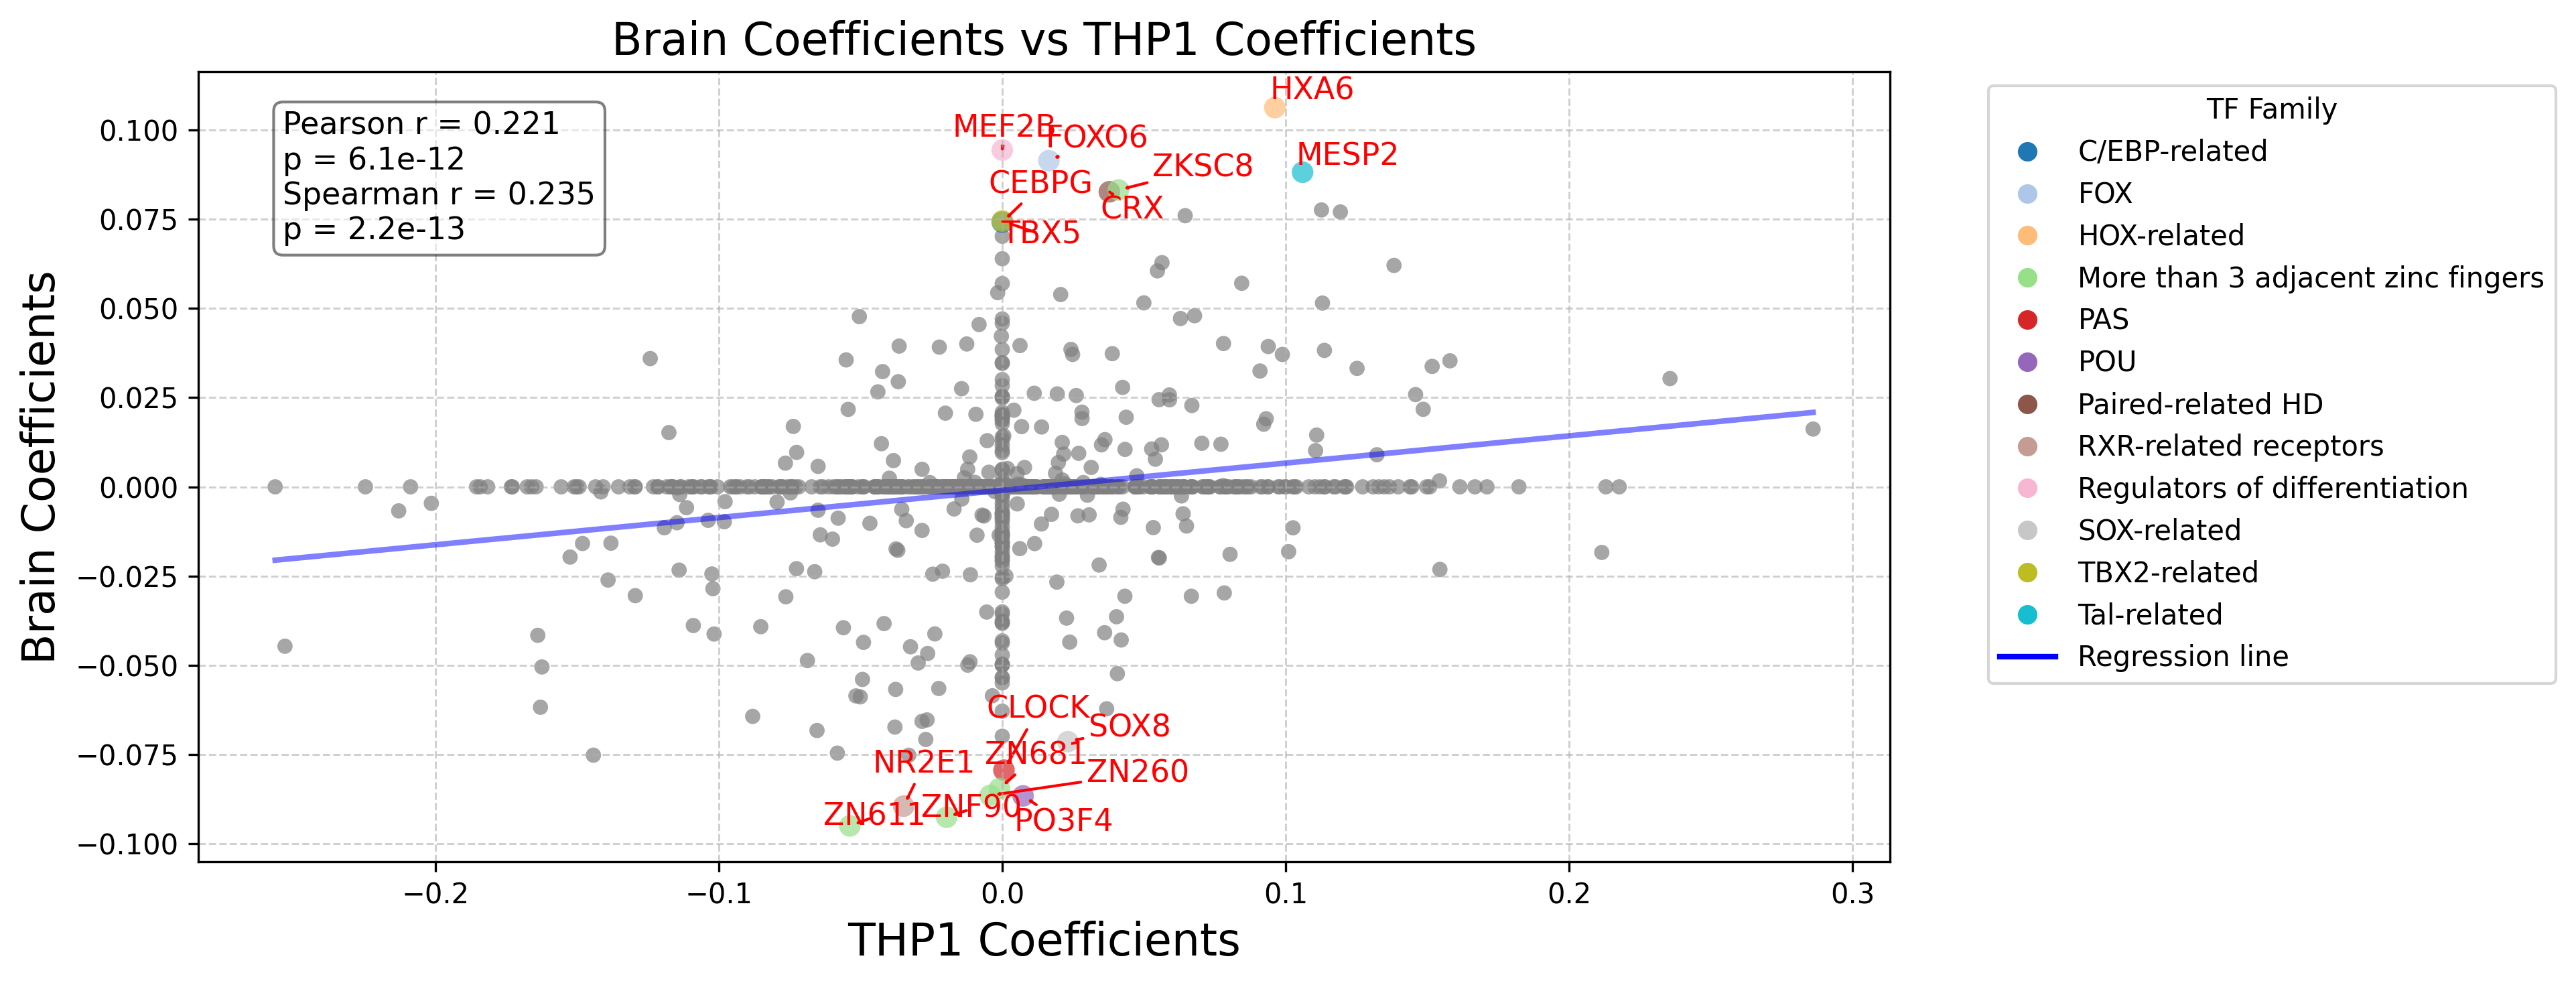

In [18]:
annotated_df_thp1=pd.read_csv('/media/zihengc/T7/mpra3_lib_analysis/MAD_TF_regression_coefficient/annotated_df_thp1.csv',index_col=0) 
annotated_df_brain=pd.read_csv('/media/zihengc/T7/mpra3_lib_analysis/MAD_TF_regression_coefficient/annotated_df_brain.csv' ,index_col=0)
fig, ax = plot_elastic_coefficients(annotated_df_thp1, annotated_df_brain,xlabel = "THP1 Coefficients",ylabel = "Brain Coefficients",threshold_outlier=3.5)
fig.savefig("thp1_brain_elasticnet_coefficients_plot.pdf",dpi=300)  # If you want to save the figure


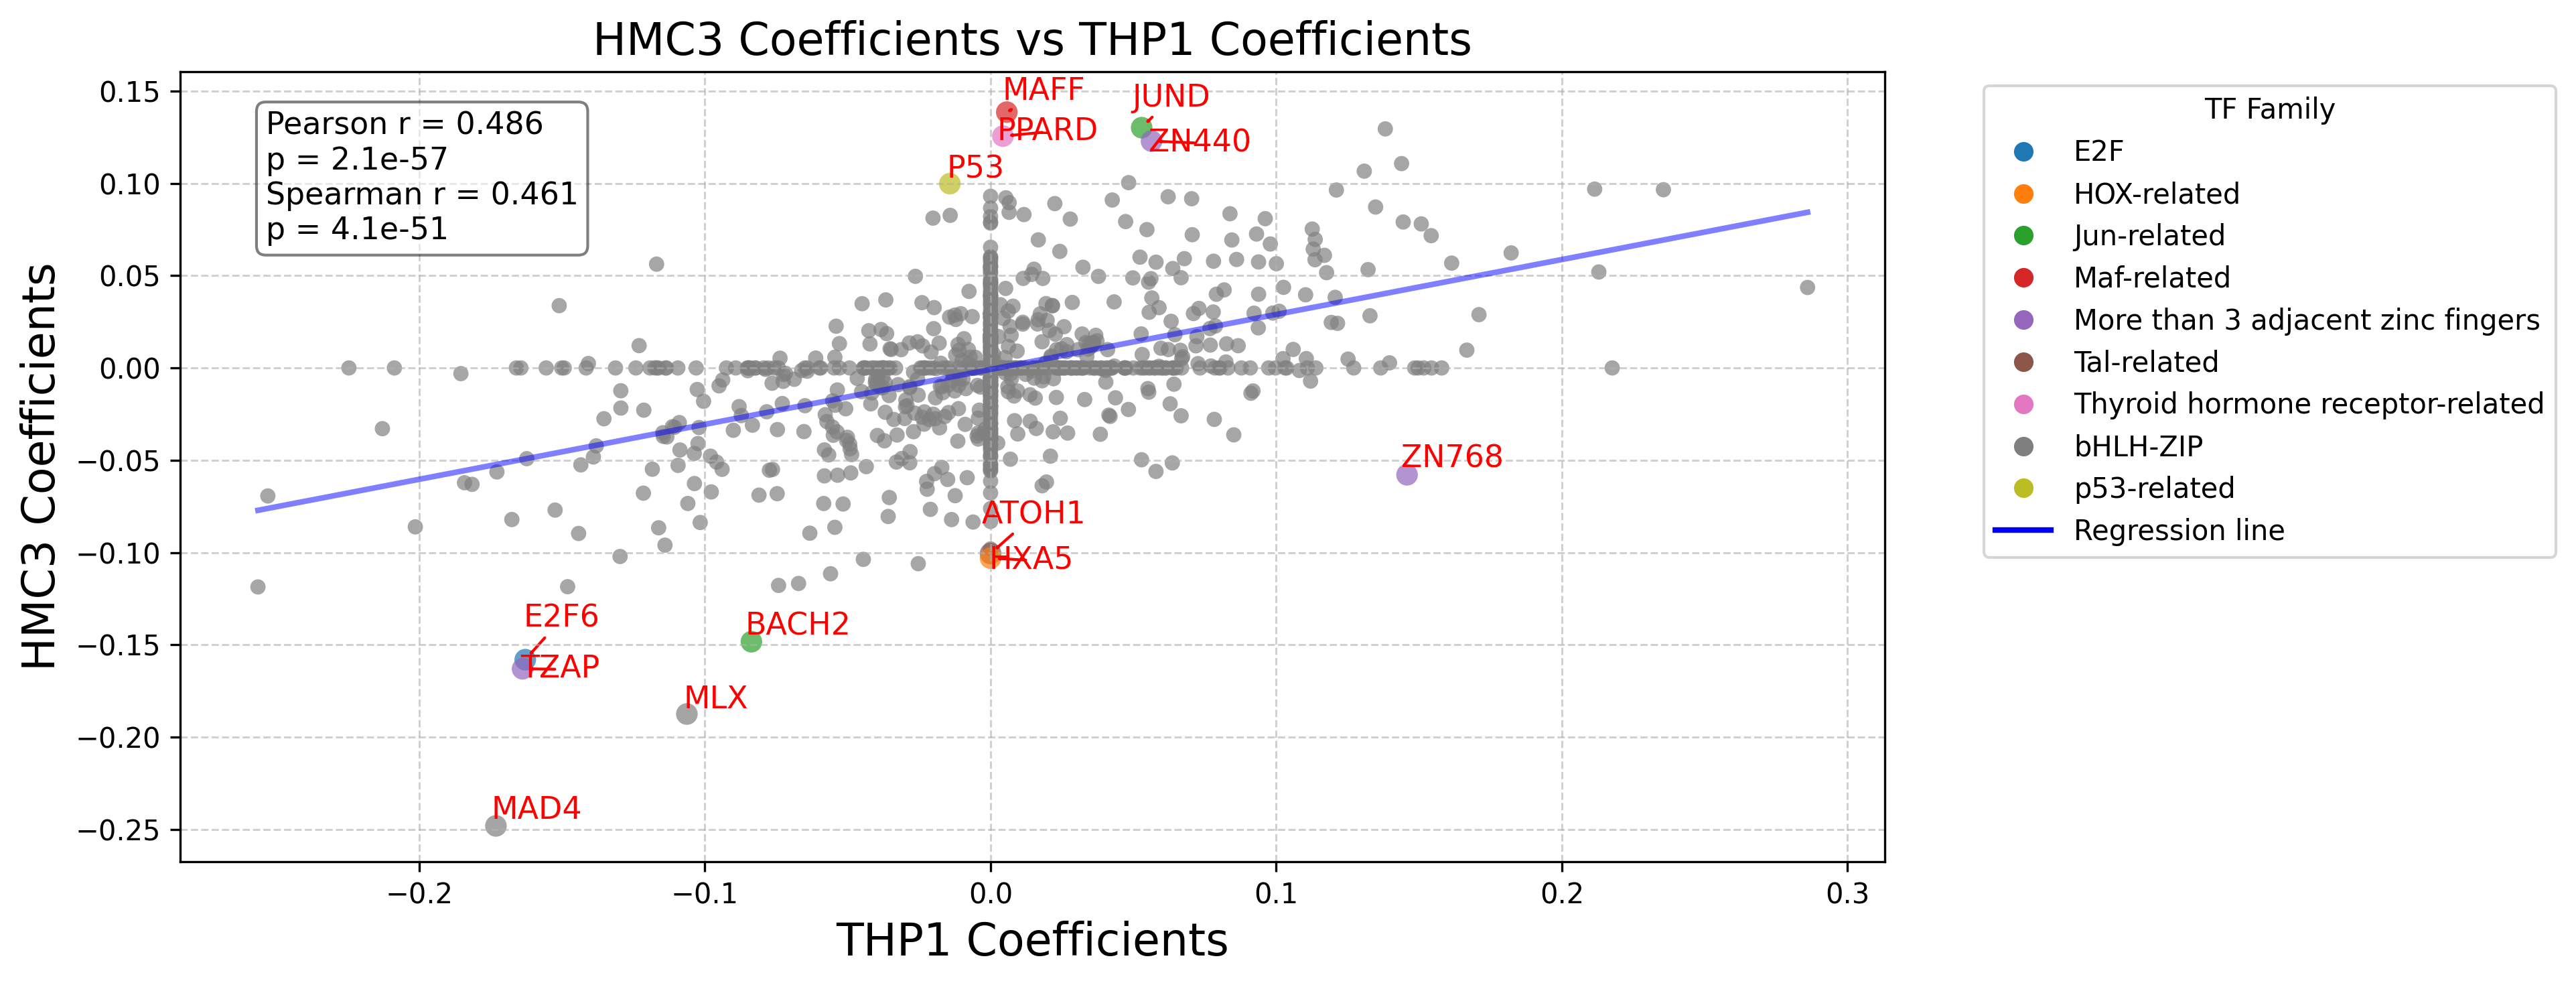

In [ ]:
fig, ax = plot_elastic_coefficients(annotated_df_thp1, annotated_df_hmc3, annotated_df_hmc3,xlabel = "THP1 Coefficients",ylabel = "HMC3 Coefficients")
fig.savefig("thp1_hmc3_elasticnet_coefficients_plot.pdf",dpi=300)  # If you want to save the figure


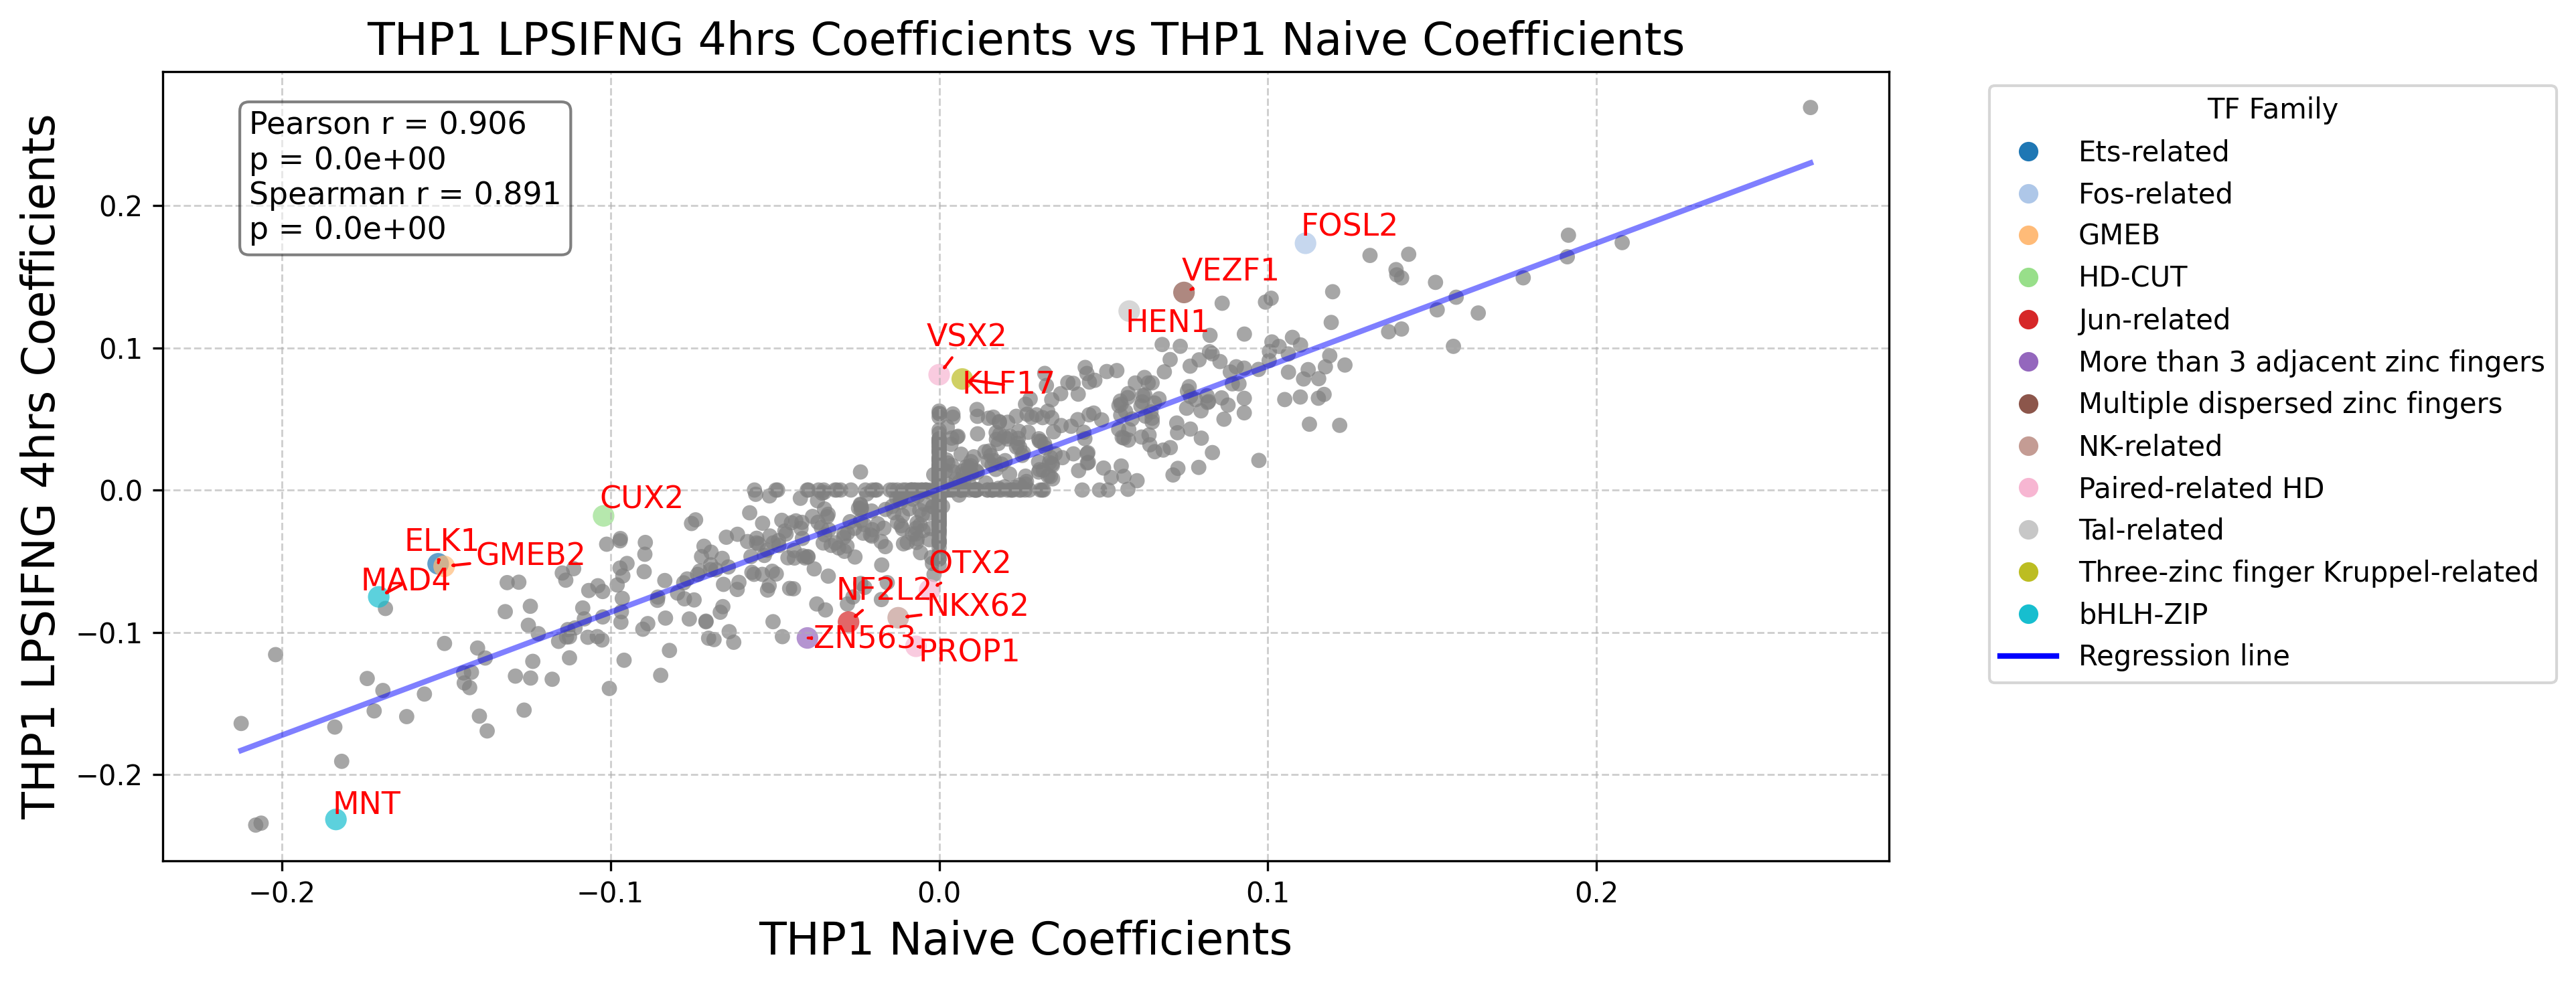

In [ ]:
fig, ax = plot_elastic_coefficients(annotated_df_naive, annotated_df_lps, annotated_df_hmc3,xlabel = "THP1 Naive Coefficients",ylabel = "THP1 LPSIFNG 4hrs Coefficients")
fig.savefig("thp1_lps_naive_elasticnet_coefficients_plot.pdf",dpi=300)  # If you want to save the figure


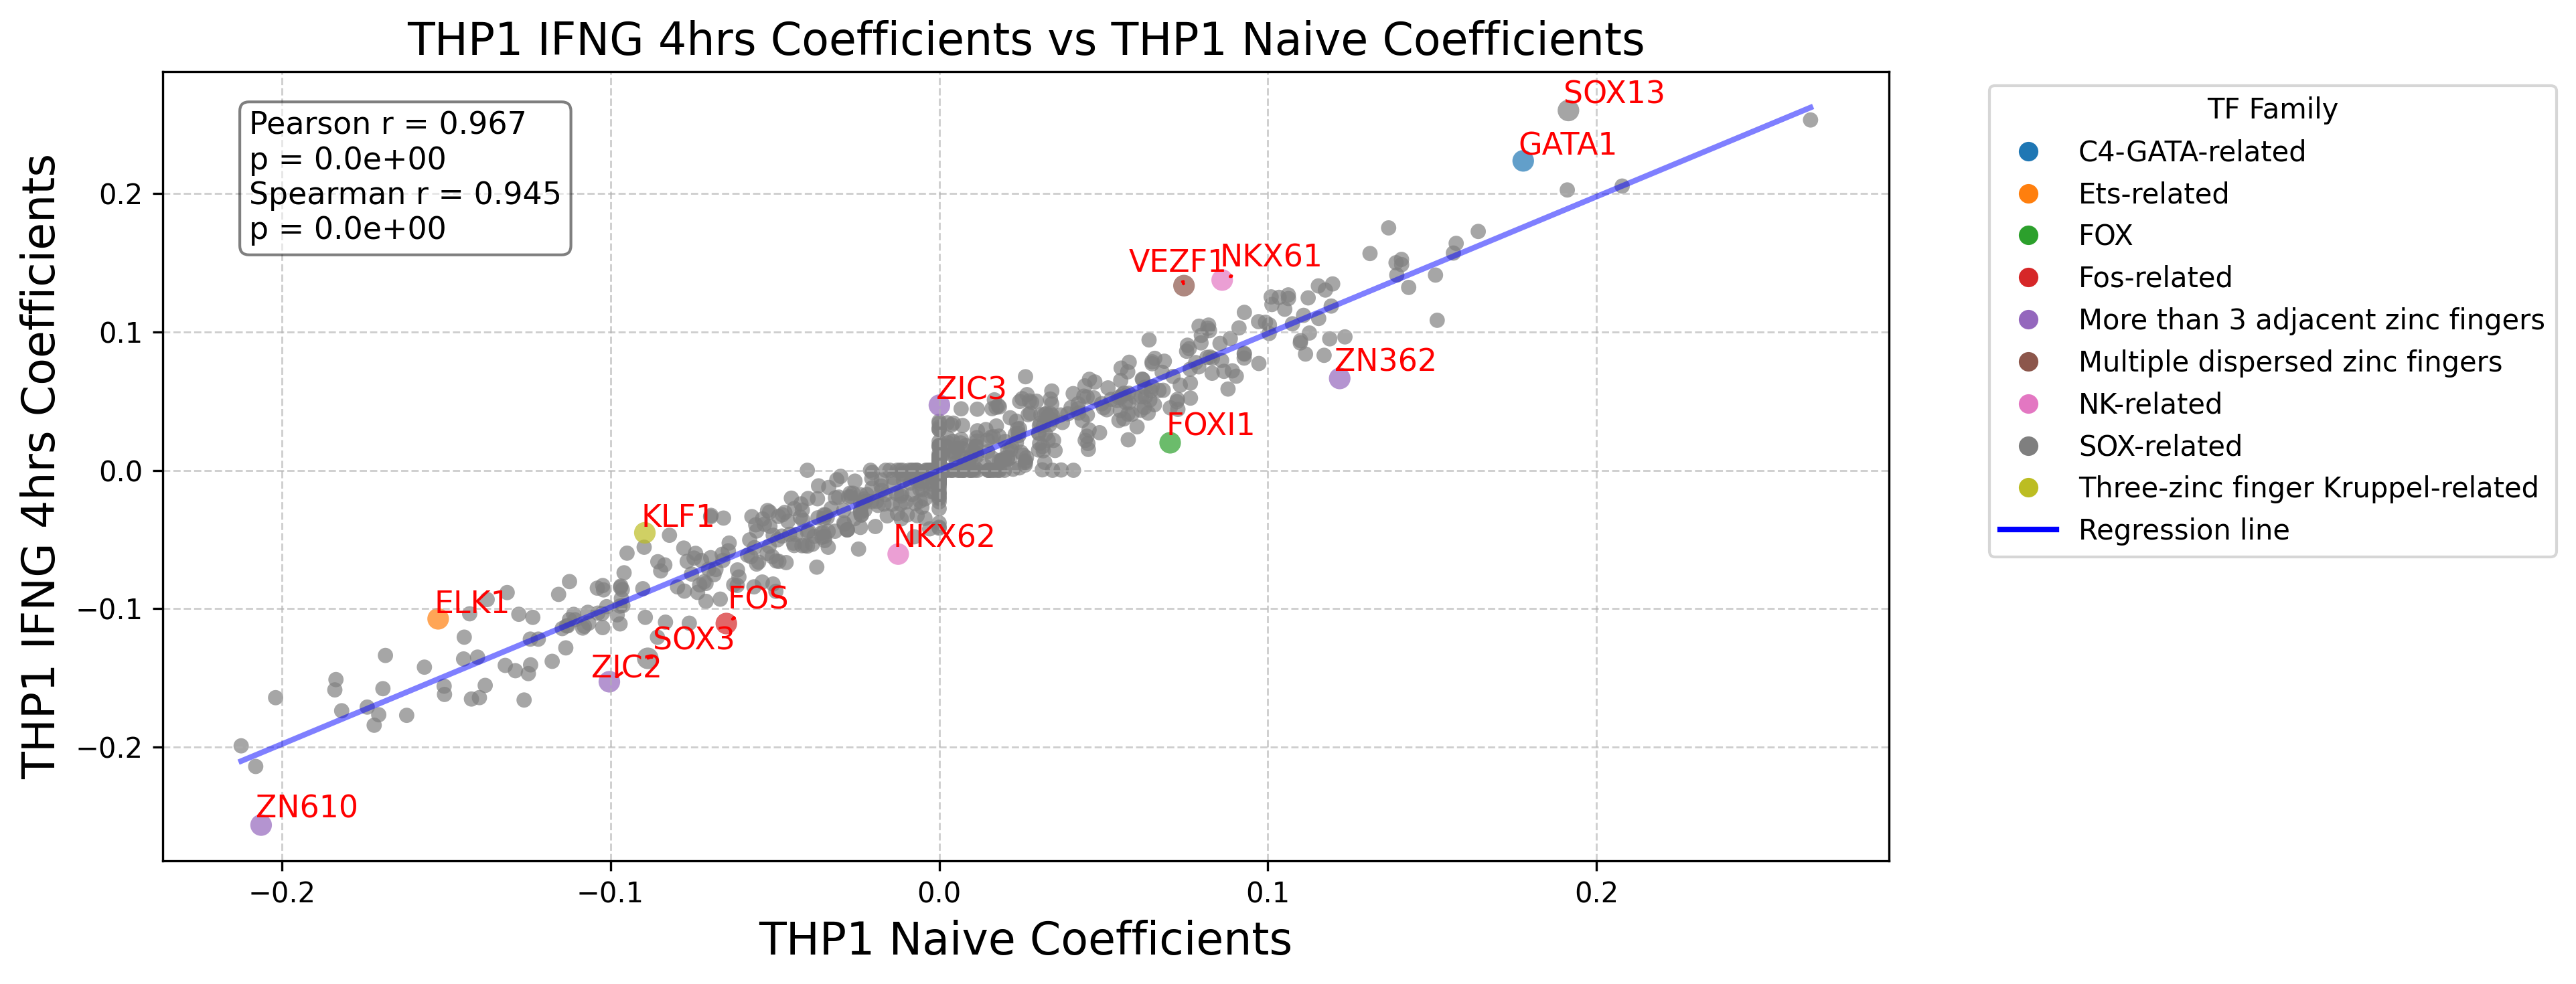

In [ ]:
fig, ax = plot_elastic_coefficients(annotated_df_naive, annotated_df_ifng, annotated_df_hmc3,xlabel = "THP1 Naive Coefficients",ylabel = "THP1 IFNG 4hrs Coefficients")
fig.savefig("thp1_ifng_naive_elasticnet_coefficients_plot.pdf",dpi=300)  # If you want to save the figure


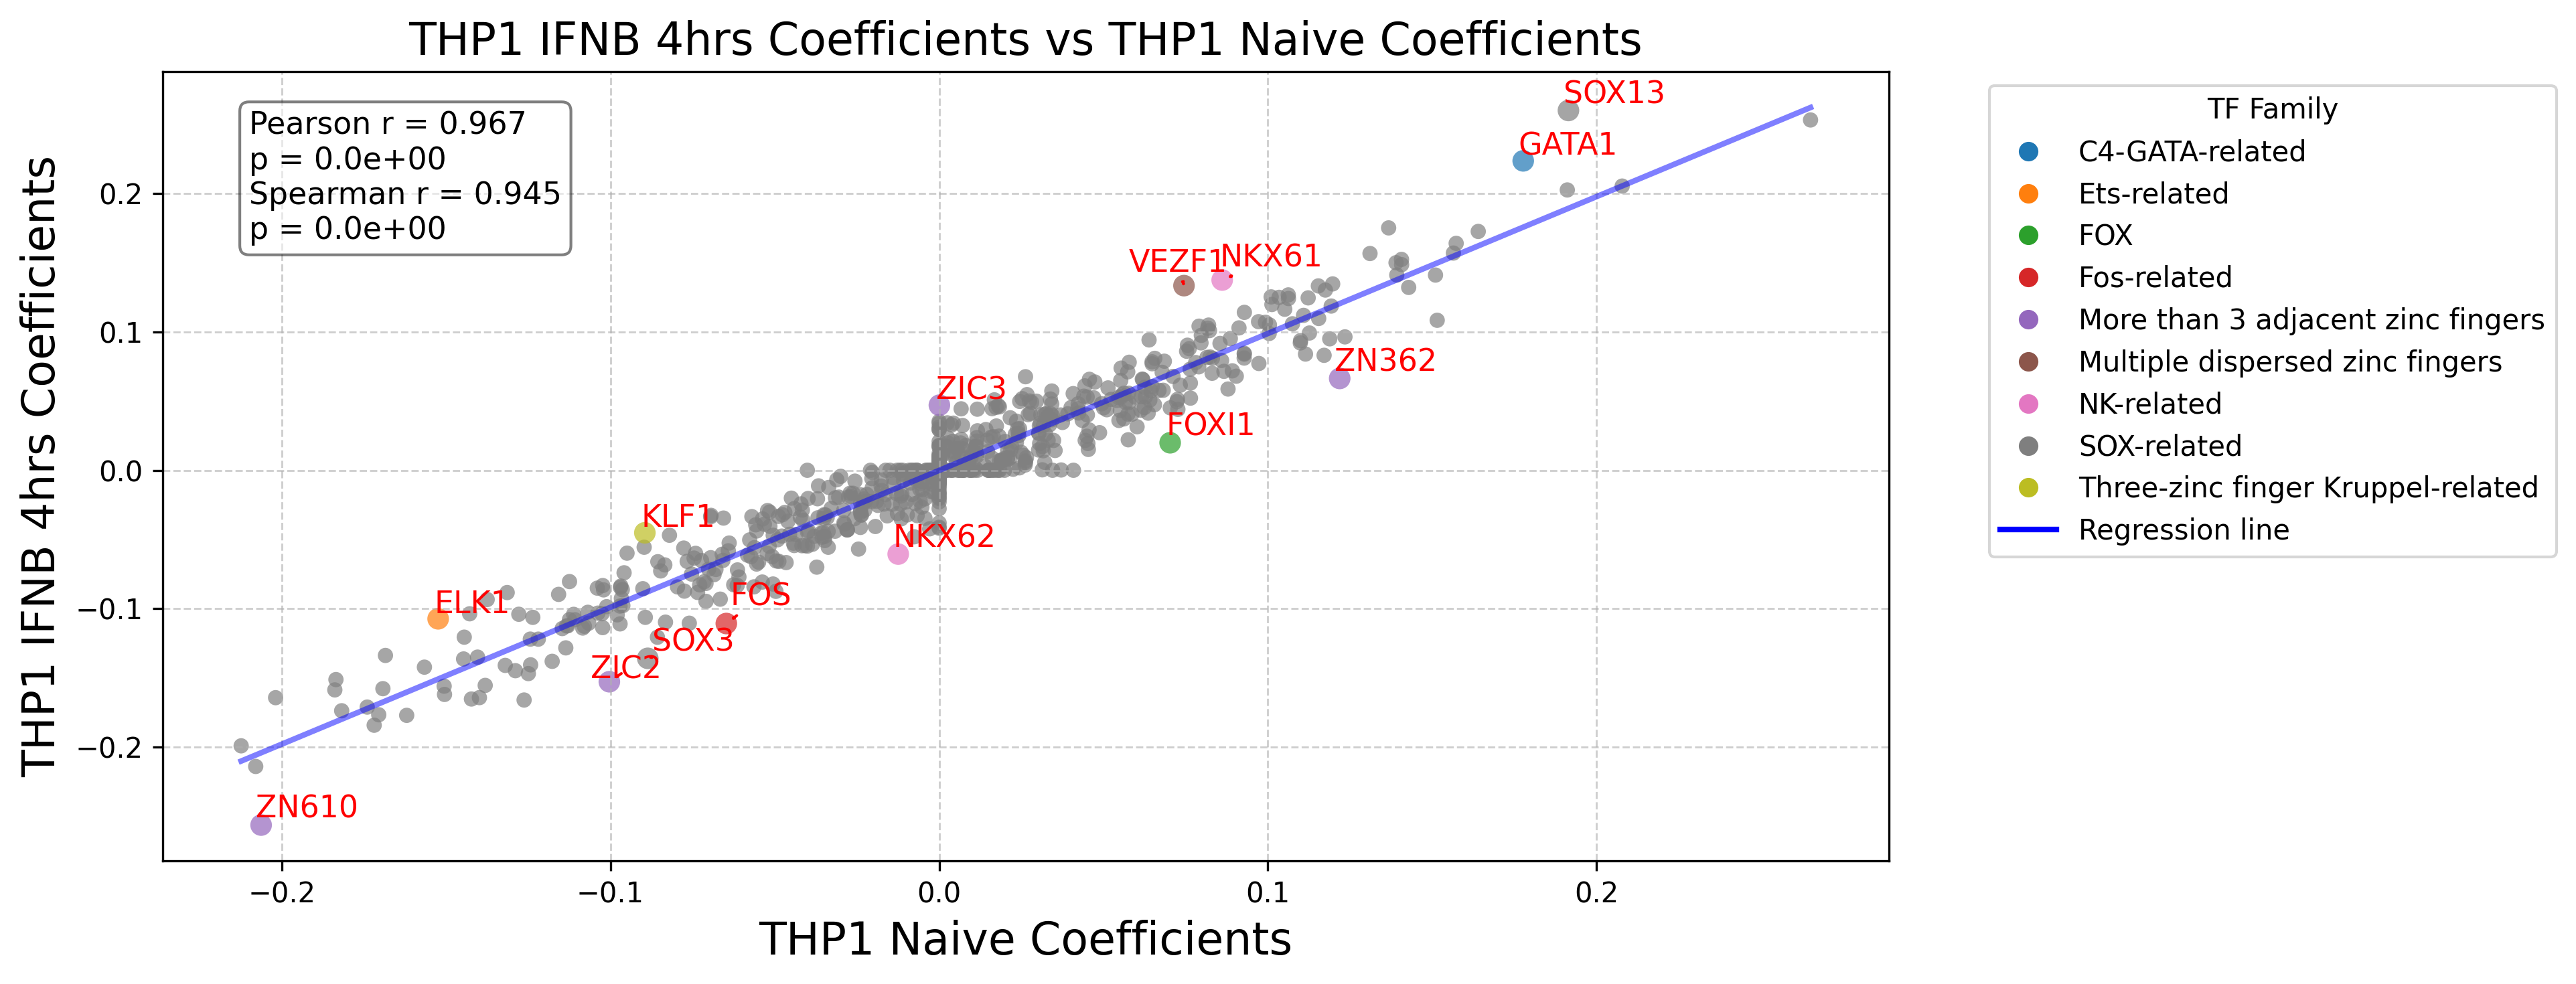

In [ ]:
fig, ax = plot_elastic_coefficients(annotated_df_naive, annotated_df_ifng, annotated_df_hmc3,xlabel = "THP1 Naive Coefficients",ylabel = "THP1 IFNB 4hrs Coefficients")
fig.savefig("thp1_ifnb_naive_elasticnet_coefficients_plot.pdf",dpi=300)  # If you want to save the figure


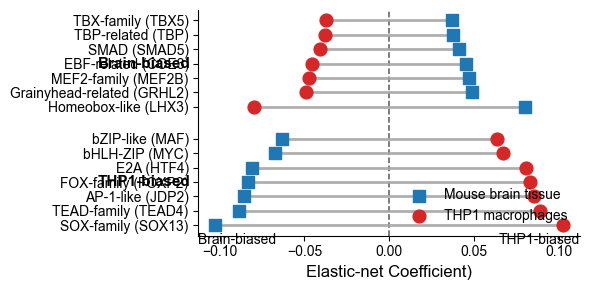

Saved:
motif_context_specific_familyaware/motif_context_specific_familyaware.png
motif_context_specific_familyaware/motif_context_specific_familyaware.pdf
motif_context_specific_familyaware/motif_context_specific_familyaware_data.csv


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Input files
# =========================
thp1_file = "/media/zihengc/T7/mpra3_lib_analysis/MAD_TF_regression_coefficient/annotated_df_thp1.csv"
brain_file = '/media/zihengc/T7/mpra3_lib_analysis/MAD_TF_regression_coefficient/annotated_df_brain.csv' 
outdir = "motif_context_specific_familyaware"
os.makedirs(outdir, exist_ok=True)

# =========================
# Load data
# =========================
thp1 = pd.read_csv(thp1_file)
brain = pd.read_csv(brain_file)

# Merge on shared annotation columns
df = thp1.merge(
    brain,
    on=["ID", "gene", "tfclass_family", "tfclass_class"],
    suffixes=("_thp1", "_brain")
).copy()

# Fallback label
df["gene"] = df["gene"].fillna("")
df["label_raw"] = df["gene"].replace("", np.nan).fillna(df["ID"])

# =========================
# Compute context-specific metrics
# =========================
df["mean_coef"] = (df["coefficient_thp1"] + df["coefficient_brain"]) / 2
df["thp1_centered"] = df["coefficient_thp1"] - df["mean_coef"]
df["brain_centered"] = df["coefficient_brain"] - df["mean_coef"]

df["delta"] = df["coefficient_thp1"] - df["coefficient_brain"]
df["abs_delta"] = df["delta"].abs()
df["absmax"] = df[["coefficient_thp1", "coefficient_brain"]].abs().max(axis=1)

# =========================
# Filter motifs
# =========================
# Remove zinc-finger-heavy / poorly interpretable noise
exclude_keywords = ["zinc", "zf", "krab", "btb"]
mask_exclude = pd.Series(False, index=df.index)

for k in exclude_keywords:
    mask_exclude |= df["tfclass_family"].fillna("").str.contains(k, case=False, regex=False)
    mask_exclude |= df["tfclass_class"].fillna("").str.contains(k, case=False, regex=False)

df = df[~mask_exclude].copy()

# Keep motifs with positive contribution in at least one context
df = df[(df["coefficient_thp1"] > 0) | (df["coefficient_brain"] > 0)].copy()

# Drop exact duplicate raw labels, keep strongest delta
df = df.sort_values("abs_delta", ascending=False).drop_duplicates(subset=["label_raw"]).copy()

# =========================
# Category assignment
# =========================
# delta > 0 : THP1-biased
# delta < 0 : Brain-biased
# small |delta| : Shared
t = 0.015

df["category"] = "Shared"
df.loc[df["delta"] > t, "category"] = "THP1-biased"
df.loc[df["delta"] < -t, "category"] = "Brain-biased"

# =========================
# Family-aware label
# Also create label_family so that only one representative
# per displayed family/class is kept in the final figure
# =========================
def assign_family_and_label(row):
    fam = str(row["tfclass_family"]) if pd.notna(row["tfclass_family"]) else ""
    cls = str(row["tfclass_class"]) if pd.notna(row["tfclass_class"]) else ""
    gene = str(row["label_raw"])

    fam_upper = fam.upper()
    cls_upper = cls.upper()
    gene_upper = gene.upper()

    # SOX
    if "SOX" in fam_upper or gene_upper.startswith("SOX"):
        return "SOX-family", f"SOX-family ({gene})"

    # FOX
    if "FOX" in fam_upper or gene_upper.startswith("FOX"):
        return "FOX-family", f"FOX-family ({gene})"

    # MEF2
    if "MEF2" in fam_upper or gene_upper.startswith("MEF2"):
        return "MEF2-family", f"MEF2-family ({gene})"

    # GATA
    if "GATA" in fam_upper or gene_upper.startswith("GATA"):
        return "GATA-family", f"GATA-family ({gene})"

    # TEAD
    if "TEAD" in fam_upper or gene_upper.startswith("TEAD"):
        return "TEAD-family", f"TEAD-family ({gene})"

    # TBX
    if "TBX" in fam_upper or gene_upper.startswith("TBX"):
        return "TBX-family", f"TBX-family ({gene})"

    # POU
    if "POU" in fam_upper or gene_upper.startswith("POU"):
        return "POU-family", f"POU-family ({gene})"

    # Homeobox
    if "HOMEO" in fam_upper or "HOMEO" in cls_upper:
        return "Homeobox-like", f"Homeobox-like ({gene})"

    # AP-1 related
    if gene_upper in {"FOSL2", "JDP2", "JUN", "JUND", "FOS", "FOSB", "JUNB"}:
        return "AP-1-like", f"AP-1-like ({gene})"

    # bZIP-like
    if "BZIP" in fam_upper or gene_upper in {"ATF3", "BATF", "CEBPG", "MAF", "MAFG", "NFE2L2"}:
        return "bZIP-like", f"bZIP-like ({gene})"

    # C/EBP
    if "CEBP" in gene_upper or "C/EBP" in fam_upper or "CEBP" in fam_upper:
        return "C/EBP-like", f"C/EBP-like ({gene})"

    # Nuclear receptor
    if "NUCLEAR" in fam_upper or gene_upper.startswith("NR"):
        return "Nuclear receptor-like", f"Nuclear receptor-like ({gene})"

    # Forkhead fallback
    if "FORKHEAD" in fam_upper:
        return "FOX-family", f"FOX-family ({gene})"

    # Default: use family if available
    if fam and fam.lower() != "nan":
        return fam, f"{fam} ({gene})"

    return gene, gene

df[["label_family", "label"]] = df.apply(
    lambda row: pd.Series(assign_family_and_label(row)),
    axis=1
)

# =========================
# Select motifs to plot
# =========================
n_shared = 6
n_thp1 = 10
n_brain = 10

# ---- THP1-biased ----
thp1_top = df[df["delta"] > t].nlargest(n_thp1, "abs_delta")

# ---- Brain-biased ----
brain_top = df[df["delta"] < -t].nlargest(n_brain, "abs_delta")

plot_df = pd.concat([thp1_top, brain_top]).copy()

# Keep only one representative per displayed family/class
# This resolves duplicates such as multiple AP-1-like motifs
plot_df = (
    plot_df
    .sort_values("abs_delta", ascending=False)
    .drop_duplicates(subset=["label_family"])
    .copy()
)

# Re-order groups
group_order = ["THP1-biased", "Brain-biased"]
plot_df["category"] = pd.Categorical(plot_df["category"], categories=group_order, ordered=True)
plot_df = plot_df.sort_values(["category", "abs_delta"], ascending=[True, False]).reset_index(drop=True)

# =========================
# Build y positions with gaps
# =========================
rows = []
y = 0
gap = 1.2

for group in group_order:
    sub = plot_df[plot_df["category"] == group].copy()
    for _, row in sub.iterrows():
        d = row.to_dict()
        d["y"] = y
        rows.append(d)
        y += 1
    if len(sub) > 0:
        y += gap

plot_df = pd.DataFrame(rows)

# =========================
# Plot
# =========================
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["font.family"] = "Arial"

fig, ax = plt.subplots(figsize=(6, 3))  # 2:1 ratio

# Connecting lines
for _, row in plot_df.iterrows():
    ax.plot(
        [row["brain_centered"], row["thp1_centered"]],
        [row["y"], row["y"]],
        color="0.65",
        linewidth=2.0,
        alpha=0.9,
        zorder=1
    )

# Brain points
ax.scatter(
    plot_df["brain_centered"],
    plot_df["y"],
    s=85,
    marker="s",
    color="tab:blue",
    label="Mouse brain tissue",
    zorder=3
)

# THP1 points
ax.scatter(
    plot_df["thp1_centered"],
    plot_df["y"],
    s=85,
    marker="o",
    color="tab:red",
    label="THP1 macrophages",
    zorder=3
)

# Axis limits
xmin = min(plot_df["brain_centered"].min(), plot_df["thp1_centered"].min()) - 0.01
xmax = max(plot_df["brain_centered"].max(), plot_df["thp1_centered"].max()) + 0.01
ax.set_xlim(xmin, xmax)

# Zero line
ax.axvline(0, linestyle="--", linewidth=1.1, color="0.35", zorder=0)

# Y labels
ax.set_yticks(plot_df["y"])
ax.set_yticklabels(plot_df["label"], fontsize=10)

# Axis titles
ax.set_xlabel("Elastic-net Coefficient)", fontsize=12)
#ax.set_title("Context-specific motif contributions to enhancer activity", fontsize=14)

# Group labels
for group in group_order:
    sub = plot_df[plot_df["category"] == group]
    if len(sub) == 0:
        continue
    ymid = (sub["y"].min() + sub["y"].max()) / 2
    ax.text(
        xmin - 0.02 * (xmax - xmin),
        ymid,
        group,
        ha="right",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

# Direction labels
ax.text(xmin, -1.5, "Brain-biased", ha="left", va="bottom", fontsize=10)
ax.text(xmax, -1.5, "THP1-biased", ha="right", va="bottom", fontsize=10)

# Style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, loc="lower right", fontsize=10)

plt.tight_layout()
plt.show()
# =========================
# Save
# =========================
png_path = os.path.join(outdir, "motif_context_specific_familyaware.png")
pdf_path = os.path.join(outdir, "motif_context_specific_familyaware.pdf")
csv_path = os.path.join(outdir, "motif_context_specific_familyaware_data.csv")

fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
plot_df.to_csv(csv_path, index=False)

print("Saved:")
print(png_path)
print(pdf_path)
print(csv_path)

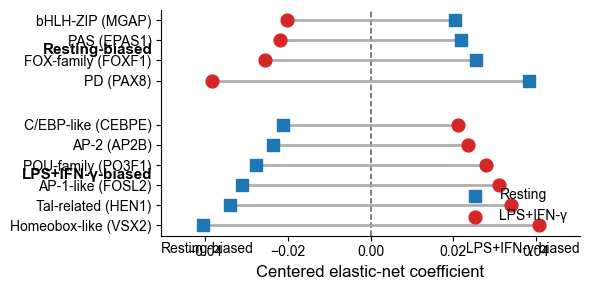

Saved:
motif_context_specific_familyaware_lpsifng_resting/motif_context_specific_familyaware_lpsifng_resting.png
motif_context_specific_familyaware_lpsifng_resting/motif_context_specific_familyaware_lpsifng_resting.pdf
motif_context_specific_familyaware_lpsifng_resting/motif_context_specific_familyaware_data_lpsifng_resting.csv


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Input files
# =========================
lpsifng_file = "/media/zihengc/T7/mpra3_lib_analysis/MAD_TF_regression_coefficient/annotated_df_lps.csv"
resting_file = "/media/zihengc/T7/mpra3_lib_analysis/MAD_TF_regression_coefficient/annotated_df_naive.csv"

outdir = "motif_context_specific_familyaware_lpsifng_resting"
os.makedirs(outdir, exist_ok=True)

# =========================
# Load data
# =========================
lpsifng = pd.read_csv(lpsifng_file)
resting = pd.read_csv(resting_file)

# Merge on shared annotation columns
df = lpsifng.merge(
    resting,
    on=["ID", "gene", "tfclass_family", "tfclass_class"],
    suffixes=("_lpsifng", "_resting")
).copy()

# Fallback label
df["gene"] = df["gene"].fillna("")
df["label_raw"] = df["gene"].replace("", np.nan).fillna(df["ID"])

# =========================
# Compute context-specific metrics
# =========================
df["mean_coef"] = (
    df["coefficient_lpsifng"] + df["coefficient_resting"]
) / 2

df["lpsifng_centered"] = df["coefficient_lpsifng"] - df["mean_coef"]
df["resting_centered"] = df["coefficient_resting"] - df["mean_coef"]

df["delta"] = df["coefficient_lpsifng"] - df["coefficient_resting"]
df["abs_delta"] = df["delta"].abs()
df["absmax"] = df[["coefficient_lpsifng", "coefficient_resting"]].abs().max(axis=1)

# =========================
# Filter motifs
# =========================
# Remove zinc-finger-heavy / poorly interpretable noise
exclude_keywords = ["zinc", "zf", "krab", "btb"]
mask_exclude = pd.Series(False, index=df.index)

for k in exclude_keywords:
    mask_exclude |= df["tfclass_family"].fillna("").str.contains(k, case=False, regex=False)
    mask_exclude |= df["tfclass_class"].fillna("").str.contains(k, case=False, regex=False)

df = df[~mask_exclude].copy()

# Keep motifs with positive contribution in at least one context
df = df[
    (df["coefficient_lpsifng"] > 0) |
    (df["coefficient_resting"] > 0)
].copy()

# Drop exact duplicate raw labels, keep strongest delta
df = (
    df.sort_values("abs_delta", ascending=False)
      .drop_duplicates(subset=["label_raw"])
      .copy()
)

# =========================
# Category assignment
# =========================
# delta > 0 : LPS+IFN-γ-biased
# delta < 0 : Resting-biased
# small |delta| : Shared
t = 0.015

df["category"] = "Shared"
df.loc[df["delta"] > t, "category"] = "LPS+IFN-γ-biased"
df.loc[df["delta"] < -t, "category"] = "Resting-biased"

# =========================
# Family-aware label
# =========================
def assign_family_and_label(row):
    fam = str(row["tfclass_family"]) if pd.notna(row["tfclass_family"]) else ""
    cls = str(row["tfclass_class"]) if pd.notna(row["tfclass_class"]) else ""
    gene = str(row["label_raw"])

    fam_upper = fam.upper()
    cls_upper = cls.upper()
    gene_upper = gene.upper()

    # SOX
    if "SOX" in fam_upper or gene_upper.startswith("SOX"):
        return "SOX-family", f"SOX-family ({gene})"

    # FOX
    if "FOX" in fam_upper or gene_upper.startswith("FOX"):
        return "FOX-family", f"FOX-family ({gene})"

    # MEF2
    if "MEF2" in fam_upper or gene_upper.startswith("MEF2"):
        return "MEF2-family", f"MEF2-family ({gene})"

    # GATA
    if "GATA" in fam_upper or gene_upper.startswith("GATA"):
        return "GATA-family", f"GATA-family ({gene})"

    # TEAD
    if "TEAD" in fam_upper or gene_upper.startswith("TEAD"):
        return "TEAD-family", f"TEAD-family ({gene})"

    # TBX
    if "TBX" in fam_upper or gene_upper.startswith("TBX"):
        return "TBX-family", f"TBX-family ({gene})"

    # POU
    if "POU" in fam_upper or gene_upper.startswith("POU"):
        return "POU-family", f"POU-family ({gene})"

    # Homeobox
    if "HOMEO" in fam_upper or "HOMEO" in cls_upper:
        return "Homeobox-like", f"Homeobox-like ({gene})"

    # AP-1 related
    if gene_upper in {"FOSL2", "JDP2", "JUN", "JUND", "FOS", "FOSB", "JUNB"}:
        return "AP-1-like", f"AP-1-like ({gene})"

    # bZIP-like
    if "BZIP" in fam_upper or gene_upper in {"ATF3", "BATF", "CEBPG", "MAF", "MAFG", "NFE2L2"}:
        return "bZIP-like", f"bZIP-like ({gene})"

    # C/EBP
    if "CEBP" in gene_upper or "C/EBP" in fam_upper or "CEBP" in fam_upper:
        return "C/EBP-like", f"C/EBP-like ({gene})"

    # Nuclear receptor
    if "NUCLEAR" in fam_upper or gene_upper.startswith("NR"):
        return "Nuclear receptor-like", f"Nuclear receptor-like ({gene})"

    # Forkhead fallback
    if "FORKHEAD" in fam_upper:
        return "FOX-family", f"FOX-family ({gene})"

    # Default: use family if available
    if fam and fam.lower() != "nan":
        return fam, f"{fam} ({gene})"

    return gene, gene

df[["label_family", "label"]] = df.apply(
    lambda row: pd.Series(assign_family_and_label(row)),
    axis=1
)

# =========================
# Select motifs to plot
# =========================
n_lpsifng = 10
n_resting = 10

# ---- LPS+IFN-γ-biased ----
lpsifng_top = df[df["delta"] > t].nlargest(n_lpsifng, "abs_delta")

# ---- Resting-biased ----
resting_top = df[df["delta"] < -t].nlargest(n_resting, "abs_delta")

plot_df = pd.concat([lpsifng_top, resting_top]).copy()

# Keep only one representative per displayed family/class
plot_df = (
    plot_df
    .sort_values("abs_delta", ascending=False)
    .drop_duplicates(subset=["label_family"])
    .copy()
)

# Re-order groups
group_order = ["LPS+IFN-γ-biased", "Resting-biased"]
plot_df["category"] = pd.Categorical(
    plot_df["category"],
    categories=group_order,
    ordered=True
)

plot_df = (
    plot_df
    .sort_values(["category", "abs_delta"], ascending=[True, False])
    .reset_index(drop=True)
)

# =========================
# Build y positions with gaps
# =========================
rows = []
y = 0
gap = 1.2

for group in group_order:
    sub = plot_df[plot_df["category"] == group].copy()
    for _, row in sub.iterrows():
        d = row.to_dict()
        d["y"] = y
        rows.append(d)
        y += 1
    if len(sub) > 0:
        y += gap

plot_df = pd.DataFrame(rows)

# =========================
# Plot
# =========================
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["font.family"] = "Arial"

fig, ax = plt.subplots(figsize=(6, 3))

# Connecting lines
for _, row in plot_df.iterrows():
    ax.plot(
        [row["resting_centered"], row["lpsifng_centered"]],
        [row["y"], row["y"]],
        color="0.65",
        linewidth=2.0,
        alpha=0.9,
        zorder=1
    )

# Resting points
ax.scatter(
    plot_df["resting_centered"],
    plot_df["y"],
    s=85,
    marker="s",
    color="tab:blue",
    label="Resting",
    zorder=3
)

# LPS+IFN-γ points
ax.scatter(
    plot_df["lpsifng_centered"],
    plot_df["y"],
    s=85,
    marker="o",
    color="tab:red",
    label="LPS+IFN-γ",
    zorder=3
)

# Axis limits
xmin = min(plot_df["resting_centered"].min(), plot_df["lpsifng_centered"].min()) - 0.01
xmax = max(plot_df["resting_centered"].max(), plot_df["lpsifng_centered"].max()) + 0.01
ax.set_xlim(xmin, xmax)

# Zero line
ax.axvline(0, linestyle="--", linewidth=1.1, color="0.35", zorder=0)

# Y labels
ax.set_yticks(plot_df["y"])
ax.set_yticklabels(plot_df["label"], fontsize=10)

# Axis title
ax.set_xlabel("Centered elastic-net coefficient", fontsize=12)

# Group labels
for group in group_order:
    sub = plot_df[plot_df["category"] == group]
    if len(sub) == 0:
        continue

    ymid = (sub["y"].min() + sub["y"].max()) / 2

    ax.text(
        xmin - 0.02 * (xmax - xmin),
        ymid,
        group,
        ha="right",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

# Direction labels
ax.text(
    xmin,
    -1.5,
    "Resting-biased",
    ha="left",
    va="bottom",
    fontsize=10
)

ax.text(
    xmax,
    -1.5,
    "LPS+IFN-γ-biased",
    ha="right",
    va="bottom",
    fontsize=10
)

# Style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, loc="lower right", fontsize=10)

plt.tight_layout()
plt.show()

# =========================
# Save
# =========================
png_path = os.path.join(outdir, "motif_context_specific_familyaware_lpsifng_resting.png")
pdf_path = os.path.join(outdir, "motif_context_specific_familyaware_lpsifng_resting.pdf")
csv_path = os.path.join(outdir, "motif_context_specific_familyaware_data_lpsifng_resting.csv")

fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
plot_df.to_csv(csv_path, index=False)

print("Saved:")
print(png_path)
print(pdf_path)
print(csv_path)